## DATA 501 — Python Module Project
### Ride Knox, 2026 h1: "Did the Day Pass Work?"

**Name:** *(Charles Munga Muiruri)*

**NetID:** *cmuiruri*

**Ride Knox 2026 half 1**

| Date | Event |
|---|---|
| July 1, 2025 | Casual single-ride price increase |
| February 2026 | S06 (Hodges Library) and S08 (Student Union - UT) expanded 24 to 32 docks |
| March 1, 2026 | **Day Pass** product launch (recorded as its own `rider_type`) |
| March 1, 2026 | Station **S25** (Cumberland Ave & 22nd St) opens, 16 docks, at **Fort Sanders** |

Three questions from the manager: `did the Day Pass bring casual riders back?`; `did the
dock expansion and the new station fix the campus crunch?`; and `who are the day-pass riders?`.

#### Setup files used
`trips_2025.csv`, `stations.xlsx`, `trips_2026_h1.csv`, and `stations_2026.xlsx` from
the same folder as this notebook. The raw files are never touched or modified.

#### How to read this notebook
-Notebook runs top to bottom as a document 
-Every cleaning step prints its row-count change, and
-**DECISION** cell/markdown states what I did and why

#### Tools  from modules 1 to 4 used
pandas (`read_csv`/`read_excel`, `.info()`, `.dtypes`, `.isna()`,
`.value_counts()`, `.unique()`/`.nunique()`, `.duplicated()`, `.describe()`,
`.drop_duplicates()`, boolean filtering, `.str` and `.dt` accessors, `.isin()`,
`.groupby()` with `.size()`/`.agg()`/`.describe()`/`.quantile()`, `.unstack()`,
`pd.merge()`, `.sort_values()`) and matplotlib (`plot`, `bar`, `barh`, `subplots`, `savefig`). 

#### Out-of-scope command invoked
`fillna(0)` for missing values needed for arithmetic operations

### Setup

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

print("pandas version:", pd.__version__)
print("working directory:", os.getcwd())

pandas version: 3.0.3
working directory: C:\Users\cmuiruri\Notebooks_Python


### reconciling the 2025 rules
**What I did:** adopted the Assignment 4 conventions — lowercase rider types,
`duration_min`, a 1 minute – 24 hour validity window, and `drop_duplicates()` with the
default `keep`. These *identical* rules applied to the 2026 file.

**Why:** the 2025 baseline at 247,967 rows already-graded. Reusing it keeps this project 
continuous with the work leadership already acted on.  
**unlimited rides for one day**,
The 24-hour ceiling treats all three rider types the same way.
**Exact duplicates** I keep the first copy rather than the last since duplicated rows in
both files are byte-identical, so `keep="first"` and `keep="last"` produce the same
dataset.

In [2]:
# 2025 base line that we already know from module 4
import pandas as pd
import matplotlib.pyplot as plt

# --- Week 3 cleaning pipeline (run as-is) ---
trips = pd.read_csv("trips_2025.csv")
stations = pd.read_excel("stations.xlsx")

trips = trips.drop_duplicates()                                    # 600 duplicate rows that are exact copies
trips = trips[trips["start_station_id"] != "S99"]                  # test station rows that must be dropped

trips["rider_type"] = trips["rider_type"].str.strip().str.lower()  # 6 spellings -> 2 (casual & member)
trips["start_station_name"] = (
    trips["start_station_name"].str.strip().str.title()
)

trips["no_end"] = trips["end_station_id"].isna()                   # keep + flag so no row omitted since this reflects a problem not a silent mistake

trips["start_time"] = pd.to_datetime(trips["start_time"])
trips["end_time"]   = pd.to_datetime(trips["end_time"])
trips["duration_min"] = (
    (trips["end_time"] - trips["start_time"]).dt.total_seconds() / 60
)
trips = trips[(trips["duration_min"] >= 1) & (trips["duration_min"] <= 24 * 60)] #keep those trips with durations greater than 1 min and less than 1 day (makes more sense)

trips["month"]      = trips["start_time"].dt.month
trips["hour"]       = trips["start_time"].dt.hour
trips["day_name"]   = trips["start_time"].dt.day_name()
trips["is_weekend"] = trips["day_name"].isin(["Saturday", "Sunday"])

trips.shape

(247967, 14)

`600 duplicate rows that are exact copies`
`test station rows that must be dropped`
`6 spellings -> 2 (casual & member)`
`keep + flag so no row omitted since this reflects a problem not a silent mistake`
`keep those trips with durations greater than 1 min and less than 1 day (makes more sense)`


In [3]:
# left-merge ended with stations on the END-station ID columns for comparison downstream
#keep only trips with a recorded end station; call it `ended`

trips["has_end"] = ~ trips["end_station_id"].isna()
ended = trips[trips["has_end"]]

merged = pd.merge(
    ended, stations,
    left_on="end_station_id", right_on="station_id",
    how="left",
)


per_station = (
    merged.groupby(["station_name", "neighborhood", "docks"])
    .size()
    .reset_index(name="arrivals_count")
)
per_station["arrivals_per_dock"] = per_station["arrivals_count"] / per_station["docks"]

per_station.sort_values("arrivals_per_dock", ascending=True)

assert len(merged) == len(ended)   # trust, but verify
print (merged.shape)

(244241, 22)


`Merging brings both trips and stations together and allows for comparisons across docks and neighborhoods`

### Intake & Cleaning 2026 Data

Runs module 2 inspection checklist on both `trips_2026_h1` & `stations_2026` files to understand structure. Arranged month by month, because of data team's note about a January app bug.

In [4]:
# Load both files for trips_2026_h1 and stations_2026 without any changes first
trips_2026 = pd.read_csv ("trips_2026_h1.csv")
stations_2026 = pd.read_excel("stations_2026.xlsx")

In [5]:
print (trips_2026.shape) #137341 rows and 8 columns
print (stations_2026.shape) #25 rows and 7 columns

(137341, 8)
(25, 7)


`original trips_2026_h1 file has 137341 rows and 8 columns`
`stations_2026 file has 25 rows and 7 columns`

In [6]:
# Understand what lives in the columns and data types by observing first 5 rows
trips_2026.head()

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type
0,T0418495,2026-01-01 00:27:32,2026-01-01 00:35:34,S05,World's Fair Park,S04,casual,electric
1,T0316555,2026-01-01 01:00:29,2026-01-01 01:20:59,S05,World's Fair Park,S11,casual,classic
2,T0388966,2026-01-01 01:08:12,2026-01-01 01:17:50,S22,Tyson Park,S02,member,electric
3,T0313803,2026-01-01 01:21:39,2026-01-01 01:47:57,S21,Caswell Park,S21,casual,electric
4,T0425615,2026-01-01 01:51:41,2026-01-01 02:08:42,S02,Gay Street & Union Ave,S02,casual,classic


In [7]:
#Check what we have in the end of the file just to understand the structure
trips_2026.tail()

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type
137336,T0320827,2026-06-30 23:41:28,2026-07-01 00:04:53,S25,Cumberland Ave & 22nd St,S06,member,classic
137337,T0363202,2026-06-30 23:46:36,2026-07-01 00:06:14,S03,Krutch Park,S12,member,classic
137338,T0384914,2026-06-30 23:47:19,2026-06-30 23:56:47,S02,Gay Street & Union Ave,S10,casual,electric
137339,T0423567,2026-06-30 23:52:06,2026-07-01 00:07:09,S05,World's Fair Park,S14,casual,electric
137340,T0327036,2026-06-30 23:54:06,2026-07-01 00:01:21,S22,Tyson Park,S05,day_pass,electric


In [8]:
# shows randomly how the row values for the columns vary since it doesn't display data in sorted manner
trips_2026.sample(n=5)

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type
38651,T0406240,2026-03-25 06:06:06,2026-03-25 06:21:00,S09,Neyland Stadium,S14,member,classic
102095,T0314522,2026-05-31 18:17:29,2026-05-31 18:35:39,S04,Old City - Jackson Ave,S11,member,classic
27798,T0403774,2026-03-08 14:45:53,2026-03-08 14:57:54,S10,Ag Campus - Morgan Hall,S09,casual,classic
70346,T0324399,2026-05-01 12:32:56,2026-05-01 12:45:40,S06,Hodges Library,S08,member,classic
839,T0353881,2026-01-03 12:28:54,2026-01-03 12:37:28,S11,Cumberland Ave & 17th St,S02,member,classic


`.sample() shows randomly how the row values for the columns vary since it doesn't display data in sorted manner`

In [9]:
print(trips_2026.dtypes)

trip_id               str
start_time            str
end_time              str
start_station_id      str
start_station_name    str
end_station_id        str
rider_type            str
bike_type             str
dtype: object


**shows data types and we see that the start_time and end_time are recorded as strings which means we cannot operate on them yet*

In [10]:
stations_2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   station_id      25 non-null     str    
 1   station_name    25 non-null     str    
 2   neighborhood    25 non-null     str    
 3   latitude        25 non-null     float64
 4   longitude       25 non-null     float64
 5   docks           25 non-null     int64  
 6   year_installed  25 non-null     int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 2.3 KB


**Shows that we have 25 station names in our station file which aligns with the instructions*

In [11]:
#how much is missing, and where? 
print(trips_2026.isna().sum()) 

trip_id                  0
start_time               0
end_time               804
start_station_id         0
start_station_name       0
end_station_id        3999
rider_type               0
bike_type                0
dtype: int64


**804 missing `end_time` and 3999 missing `end_station_id`*

In [12]:
# What values live in each column?
trips_2026["rider_type"].unique()

<ArrowStringArray>
['casual', 'member', 'DAY PASS', 'day_pass', 'Day Pass']
Length: 5, dtype: str

**day_pass comes under 3 types of spelling*

In [13]:
#Checking for number of unique start_station_id, end_station_id, and rows in station_2026 to check whether we have wrong naming
print (stations_2026 ["station_name"].nunique())
print (trips_2026 ["start_station_name"].nunique()) 
print (trips_2026 ["start_station_id"].nunique()) 
print (trips_2026 ["end_station_id"].nunique()) 

25
50
25
25


**we have 50 names in `trips_2026` for 25 stations in `stations_2026` file*

In [14]:
trips_2026 ["start_station_name"].value_counts() #Names have same spelling but white spaces across the different instances

start_station_name
Market Square                   12358
Hodges Library                  12355
Student Union - UT              11905
Cumberland Ave & 17th St         8967
Gay Street & Union Ave           8934
World's Fair Park                8309
Old City - Jackson Ave           7713
The Hill - Ayres Hall            6840
Neyland Stadium                  6804
Cumberland Ave & 22nd St         6357
Krutch Park                      5761
Fort Sanders - Laurel Ave        4383
South Waterfront                 4332
Ag Campus - Morgan Hall          3912
Happy Holler                     3755
Tyson Park                       3605
Second Creek Greenway            3183
Broadway & Central               2707
Fourth & Gill                    2469
Ijams Nature Center              2303
Bearden - Kingston Pike          2232
Suttree Landing Park             2038
Zoo Knoxville                    1957
Caswell Park                     1491
Sequoyah Hills Park               980
  Student Union - UT           

In [15]:
print (len(stations_2026))

25


In [16]:
trips_2026 ["start_station_id"].value_counts() #All 25 stations from stations_2026 are included here

start_station_id
S01    12511
S06    12504
S08    12062
S11     9063
S02     9050
S05     8413
S04     7800
S07     6942
S09     6882
S25     6446
S03     5834
S12     4437
S14     4395
S10     3956
S17     3798
S22     3665
S13     3222
S19     2741
S18     2496
S16     2330
S23     2253
S15     2065
S20     1977
S21     1508
S24      991
Name: count, dtype: int64

In [17]:
# duplicates in trips_2026 using start_time
print (trips_2026.duplicated().sum())
print(trips_2026.duplicated(keep=False).sum())

350
700


**We have 700 rows that are exact copies and thus, we need to drop 350 of them*

In [18]:
trips_2026[trips_2026.duplicated(keep=False)].sort_values("start_time").head(4)

,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type
349,T0426558,2026-01-01 22:01:18,2026-01-01 22:15:41,S02,Gay Street & Union Ave,S13,member,classic
350,T0426558,2026-01-01 22:01:18,2026-01-01 22:15:41,S02,Gay Street & Union Ave,S13,member,classic
717,T0362078,2026-01-03 06:38:28,2026-01-03 07:01:47,S07,The Hill - Ayres Hall,S06,member,electric
718,T0362078,2026-01-03 06:38:28,2026-01-03 07:01:47,S07,The Hill - Ayres Hall,S06,member,electric


**Confirms duplicated rows are exact copies*

In [19]:
trips_2026["end_time"].isna().sum() #before removing duplicates

np.int64(804)

-We now know that stations_2026 has 25 stations. `trips_2026` has 137341 rows and 8 columns, 350 rows are duplicates and need to be dropped and 804 trips have no `end_time`

-`rider_type` for day_pass has 3 spellings (day_pass, Day Pass, DAY PASS) for the same ridership.

### Fixing what we know for now: times are str, duplicates, missing end_time, missing end_station_id, white spaces, imposters

In [20]:
#Dropping duplicates
trips_2026 = trips_2026.drop_duplicates() #dropped 350 duplicates
trips_2026.shape

(136991, 8)

**From 137341 rows and 8 columns to 136991 rows and 8 columns after dropping 350 rows*

In [21]:
trips_2026["end_time"].isna().sum() #after removing duplicates

np.int64(800)

**Confirm the new number of rows without `end_time` after we drop duplicates and we move from 804 to 800 rows with no `end_time`*

In [22]:
trips_2026["start_station_name"] = trips_2026["start_station_name"].str.strip()  # 50 spellings -> 25 as per the stations_2026
trips_2026["rider_type"] = (   #from 5 spelling to only 3 casual, member & day_pass
    trips_2026["rider_type"]
        .str.strip()
        .str.title()
        .str.replace(" ", "_")
        .str.lower()
)
trips_2026["rider_type"].unique()

<ArrowStringArray>
['casual', 'member', 'day_pass']
Length: 3, dtype: str

**We keep the day_pass as the correct naming to maintain variable naming rule and we confirm the fix*

In [23]:
#Flagging trips with no end_station_id and no end_time instead of dropping since they still reflect a possible problem Ride Knox hasn't fixed

trips_2026["no_end_station"] = trips_2026["end_station_id"].isna()  # keep + flag so no row omitted 

trips_2026["no_end_time"] = trips_2026 ["end_time"].isna() # keep + flag so no row omitted

print (trips_2026["end_station_id"].isna().sum())
print (trips_2026 ["end_time"].isna().sum())

3990
800


**Flagging trips with no end_station_id and no end_time instead of dropping since they still reflect a possible problem Ride Knox hasn't fixed*

In [24]:
#Using .dt accessor to change time to integer type from text for calculating durations

trips_2026["start_time"] = pd.to_datetime(trips_2026["start_time"])
trips_2026["end_time"]   = pd.to_datetime(trips_2026["end_time"])
trips_2026["duration_min"] = (
    (trips_2026["end_time"] - trips_2026["start_time"]).dt.total_seconds() / 60
)

print ((trips_2026["duration_min"] < 0).sum()) #negative trips
print ((trips_2026["duration_min"] > 24 * 60).sum()) #trips longer than 24 hours

180
240


**we have 180 -ve trips and 240 trips lasting more than a day which is not practical.*

In [25]:
#Let's establish a practical threshold whereby we shall consider trips taking between 1 min and 24 hours

trips_2026 = trips_2026[
    trips_2026["no_end_time"] |
    ((trips_2026["duration_min"] >= 1) & (trips_2026["duration_min"] <= 24 * 60))] #keep those trips with durations that make sense

trips_2026["month"]      = trips_2026["start_time"].dt.month
trips_2026["hour"]       = trips_2026["start_time"].dt.hour
trips_2026["day_name"]   = trips_2026["start_time"].dt.day_name()
trips_2026["is_weekend"] = trips_2026["day_name"].isin(["Saturday", "Sunday"])
trips_2026["is_weekday"] = ~ trips_2026["day_name"].isin(["Saturday", "Sunday"])

In [26]:
print (trips_2026.shape) #new shape is 136411 rows and 17 columns
trips_2026.tail() #we have new columns with duration_min and the ones without end_time flagged

(136411, 16)


,trip_id,start_time,end_time,start_station_id,start_station_name,end_station_id,rider_type,bike_type,no_end_station,no_end_time,duration_min,month,hour,day_name,is_weekend,is_weekday
137336,T0320827,2026-06-30 23:41:28,2026-07-01 00:04:53,S25,Cumberland Ave & 22nd St,S06,member,classic,False,False,23.416667,6,23,Tuesday,False,True
137337,T0363202,2026-06-30 23:46:36,2026-07-01 00:06:14,S03,Krutch Park,S12,member,classic,False,False,19.633333,6,23,Tuesday,False,True
137338,T0384914,2026-06-30 23:47:19,2026-06-30 23:56:47,S02,Gay Street & Union Ave,S10,casual,electric,False,False,9.466667,6,23,Tuesday,False,True
137339,T0423567,2026-06-30 23:52:06,2026-07-01 00:07:09,S05,World's Fair Park,S14,casual,electric,False,False,15.050000,6,23,Tuesday,False,True
137340,T0327036,2026-06-30 23:54:06,2026-07-01 00:01:21,S22,Tyson Park,S05,day_pass,electric,False,False,7.250000,6,23,Tuesday,False,True


**New DataFrame has 136411 rows and 17 columns with valid durations that can be used for oprtaions and comparisons*

In [27]:
trips_2026["no_end_time"].value_counts() #now 800 trips have no end_time and they are flagged

no_end_time
False    135611
True        800
Name: count, dtype: int64

In [28]:
# Of the 800 rows without end_time, 781 of them have end_station_id meaning those trips were completed, but the times were never recorded 
trips_2026[trips_2026 ["no_end_time"]] ["end_station_id"].isna().value_counts()

end_station_id
False    781
True      19
Name: count, dtype: int64

In [29]:
#months when the bug affected the system
trips_2026[trips_2026 ["no_end_time"]] ["month"].value_counts() #533 trips in Jan and 267 trips in February have no end_time

month
1    533
2    267
Name: count, dtype: int64

In [30]:
#12 of the 19 trips without end_station_id occurred in Jan and the remaining 7 occurred in February
trips_2026 [trips_2026["no_end_time"] & trips_2026["end_station_id"].isna()] ["month"].value_counts()

month
1    12
2     7
Name: count, dtype: int64

In [31]:
trips_2026["no_end_station"].value_counts() #now 3967 trips have no end_station_id and are flagged

no_end_station
False    132444
True       3967
Name: count, dtype: int64

In [32]:
#value_counts on is_weekday and is_weekend
print (trips_2026["is_weekday"].value_counts()) #93645 trips for the 5 weekdays and about 42766 over the weekend
print ((trips_2026["is_weekday"].sum())/5) #about 18729 trips per every weekday
print ((trips_2026["is_weekend"].sum())/2) #about 21383 trips per every weekend day
print (f"about {(((trips_2026['is_weekday'].sum())/((trips_2026['is_weekday'].sum()) + (trips_2026['is_weekend'].sum())))*100).round(2)}% of 136411 trips happen on weekdays")

is_weekday
True     93645
False    42766
Name: count, dtype: int64
18729.0
21383.0
about 68.65% of 136411 trips happen on weekdays


**93645 of the 136411 trips happen on the weekdays representing a 68.65% completion of total trips*

In [33]:
#Summary of our trips_2026 data
#Typical casual ridership duration is 19 min, 20 min for day_pass riders and 11 min for member riders
#we have 45114 casual riders, 10886 day_pass riders and 79611 member riders
#Average durations are 22.8, 24.1 and 13.6 min for casual, daypass and member riders respectively
print (trips_2026.groupby("rider_type")["duration_min"].describe())

              count       mean        std       min        25%        50%  \
rider_type                                                                  
casual      45114.0  22.871501  15.359980  1.616667  12.633333  19.033333   
day_pass    10886.0  24.086905  15.733610  2.383333  13.266667  20.533333   
member      79611.0  13.576551   8.202712  1.283333   7.950000  11.650000   

                  75%         max  
rider_type                         
casual      28.616667  197.033333  
day_pass    30.383333  193.983333  
member      16.933333  160.433333  


**Typical casual ridership duration is 19 min, 20 min for day_pass riders and 11 min for member riders*

**we have `45114 casual riders`, `10886 day_pass riders` and `79611 member riders` (Member riders are more than casual, and day_pass riders)* 

**`Average durations` are 22.8, 24.1 and 13.6 min for `casual`, `day_pass` and `member riders` respectively*

In [34]:
#agg by month: trip count + average duration_min
#The trips increase from 10182 trips in Jan to 34786 in June with average ridership durations oscillating between 16.5 min to 18 min
trips_2026.groupby("month").agg(
    trip_count=("trip_id", "count"),
    avg_min=("duration_min", "mean"),
)

,trip_count,avg_min
month,,
1,10182,16.764039
2,12616,16.559893
3,20156,17.177364
4,26507,17.594842
5,32164,17.705617
6,34786,18.010881


**Highest trips, 34786, happened in June and the lowest, 10182, in January.*

In [35]:
#What is the monthly `ridership` trend for the three rider types?
trips_2026.groupby(["month", "rider_type"]).size().unstack()

rider_type,casual,day_pass,member
month,,,
1,3441.0,NaN,6741.0
2,4261.0,NaN,8355.0
3,6697.0,1111.0,12348.0
4,8898.0,2240.0,15369.0
5,10746.0,3418.0,18000.0
6,11344.0,4117.0,19325.0


**The monthly trend shows that ridership for all three rider_types increases from January to June*

Member ridership is highest for all six months*

### Findings
**(i) Problems that carried over from 2025*
-Exact duplicate rows from double submission 350 in 2026, 600 in 2025

-Missing `end_station_id` for 3,999 trips in 2026 while  2025 had 3,774 showing that error increases.

-Whitespaces on `start_station_name` with 50 spellings for 25 stations, while 2025 had 121 spellings for 24 station names.

-240 trips over 24 hours and 180 negative trips.

**(ii) 2025 problems fixed at source*

**The S99 test station is gone.* 2025 had 263 trips starting at a station that existed
  in no directory; 2026 has zero. 
  
**`rider_type` casing for members and casuals is clean but day_pass needed different handling.** unlike 2025 that had 6 spellings for two
  categories.
  
**Station-name casing is clean.* 121 spellings in 2025 down to 50 in 2026.

**(iii) New in 2026*

**Three spellings of the new rider type:* `day_pass`, `Day Pass`and
  `DAY PASS`. 
  
**The January app bug: missing `end_time`.* 804 rows (800 after dropping duplicates).

**781 of those 804 rows still carry a valid `end_station_id`.* The trip completed and docked; only the clock reading was lost. 
  
**Dock counts changed* for S06 and S08 (24 to 32). 

The cleaned 2025 baseline is **247,967** rows. The cleaned 2026 dataset is **136,411** rows from 137,341.

### The Recovery Question
**Did non-member ridership recover?*

**What I did:** compared **January–June 2026 against January–June 2025 only*, with
identical cleaning rules applied for month-by-month comparison.

I also compared 2026 H1 dock activity against the 2025 full-year totals for the docks to see whether the same docks are ranking top.

**Cost:** the July 2025 price increase falls outside both windows, so this comparison cannot separate "the Day Pass worked" from "the price shock was wearing off anyway."

#### Month-by-month, as numbers

In [36]:
# Match January-June for both 2025 and 2026
trips_2025 = trips[trips["month"] <= 6] #for Jan to June for monthly comparisons
trips_2026 = trips_2026   # already Jan-Jun only

print (len(trips_2025)) #130084 trips for the first 6 months in 2025
print(len(trips_2026)) #136411 trips for the first 6 months in 2026
trips_2025.shape

130084
136411


(130084, 15)

**Here we can see that 2026 had 130084 trips completed in first half compared to 136411 in 2026*

In [37]:
monthly_2025 = trips_2025.groupby(["month", "rider_type"]).size().unstack()
print (monthly_2025)

rider_type  casual  member
month                     
1             4699    6092
2             5666    7614
3             8569   11156
4            11241   14155
5            13207   16406
6            13816   17463


**Ridership increases from Jan to June for both casual (13816 in June) and member(17463 in June) riders in 2025*

In [38]:
monthly_2026 = trips_2026.groupby(["month", "rider_type"]).size().unstack()
print (monthly_2026)

rider_type   casual  day_pass   member
month                                 
1            3441.0       NaN   6741.0
2            4261.0       NaN   8355.0
3            6697.0    1111.0  12348.0
4            8898.0    2240.0  15369.0
5           10746.0    3418.0  18000.0
6           11344.0    4117.0  19325.0


**Ridership increases from Jan to June for casual(11344 in June), member(19325 in June) and day_pass(4117 in June) riders in 2026 as it happened in 2025. Are the numbers higher or lower?: day_pass+casual for june 2026 are 15461 trips compared to 13816 trips for June 2025.*

In [39]:
#rider_type counts and shares 2025 h1
print (trips_2025 ["rider_type"].value_counts())
print (trips_2025 ["rider_type"].value_counts(normalize=True))
print (f" 56.0% of 130084 riders are member riders")
print (f" 44% of 130084 riders are casual riders")

rider_type
member    72886
casual    57198
Name: count, dtype: int64
rider_type
member    0.560299
casual    0.439701
Name: proportion, dtype: float64
 56.0% of 130084 riders are member riders
 44% of 130084 riders are casual riders


**rider_type counts and shares 2025 has 72886 member trips and  57198 casual trips. 56.0% of 130084 trips are made by member riders and 44% by casual riders*

In [40]:
#rider_type counts and shares 2026 h1
print (trips_2026 ["rider_type"].value_counts())
print (trips_2026 ["rider_type"].value_counts(normalize=True))
print (f" 58.7% of 136411 riders are member riders")
print (f" 33.3% of 136411 riders are casual riders")
print (f" 8% of 136411 riders are day_pass riders")

rider_type
member      80138
casual      45387
day_pass    10886
Name: count, dtype: int64
rider_type
member      0.587475
casual      0.332722
day_pass    0.079803
Name: proportion, dtype: float64
 58.7% of 136411 riders are member riders
 33.3% of 136411 riders are casual riders
 8% of 136411 riders are day_pass riders


**In 2026, of the 136411 trips made, 58.7% are member riders, 33.3% are casual riders, and 8% are day_pass riders. Casual riders drop from 57198 in 2025 to 45387 in 2026 from Jan to June. Casual+day_pass rider trips are still lower than the casual in 2025 (56273 non_members in 2026 vs 57198 casual riders in 2025)*

In [41]:
#share of trips with no recorded end station (the no_end flag)
print (trips_2026 ["no_end_time"].value_counts())
print (trips_2026 ["no_end_time"].value_counts(normalize=True))
print (trips_2026 ["no_end_station"].value_counts())
print (trips_2026 ["no_end_station"].value_counts(normalize=True))
print (f" about 0.5% of 136411 trips have no end time recorded")
print (f" about 2.9% of 136411 trips have no end station recorded")

no_end_time
False    135611
True        800
Name: count, dtype: int64
no_end_time
False    0.994135
True     0.005865
Name: proportion, dtype: float64
no_end_station
False    132444
True       3967
Name: count, dtype: int64
no_end_station
False    0.970919
True     0.029081
Name: proportion, dtype: float64
 about 0.5% of 136411 trips have no end time recorded
 about 2.9% of 136411 trips have no end station recorded


In [42]:
#Non-member share of each month's trips for 2026(non_member is defined as a casual or a day_pass rider)
monthly_2026 ["non_member"] = (monthly_2026["casual"] + monthly_2026["day_pass"].fillna(0)) / (monthly_2026["casual"] + monthly_2026["day_pass"].fillna(0) + monthly_2026["member"])*100
print (monthly_2026["non_member"])

month
1    33.794932
2    33.774572
3    38.737845
4    42.019089
5    44.036811
6    44.446042
Name: non_member, dtype: float64


**After the launch of the day_pass in March, the non_member ridership increases from the typical 33% values to 44% share of total trips*

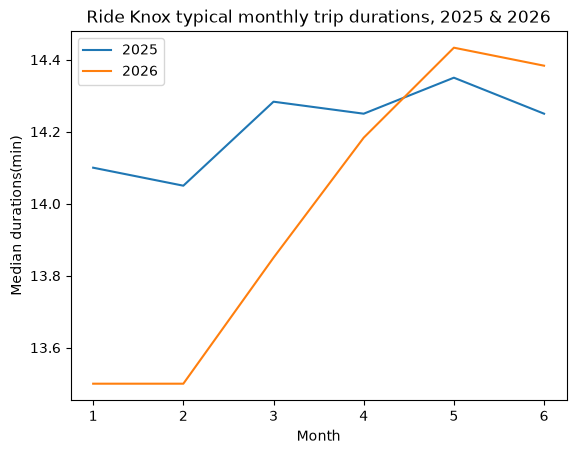

In [43]:
# Did the typical durantions per month change?
trip_length_2025 = trips_2025.groupby("month")["duration_min"].median()

trip_length = trips_2026.groupby("month")["duration_min"].median()

plt.plot(trip_length_2025.index, trip_length_2025.values, label = "2025")
plt.plot(trip_length.index, trip_length.values, label = "2026")
plt.title("Ride Knox typical monthly trip durations, 2025 & 2026")
plt.xlabel("Month") ; plt.ylabel("Median durations(min)") ; plt.legend()
plt.savefig("monthly_duration_median.png", dpi=150, bbox_inches="tight")
plt.show()

**Median durations for 2026 move from about 13.5 min to 14.5 min compared to 2025 median trends around 14.1 min showing that typical monthly durations are close*

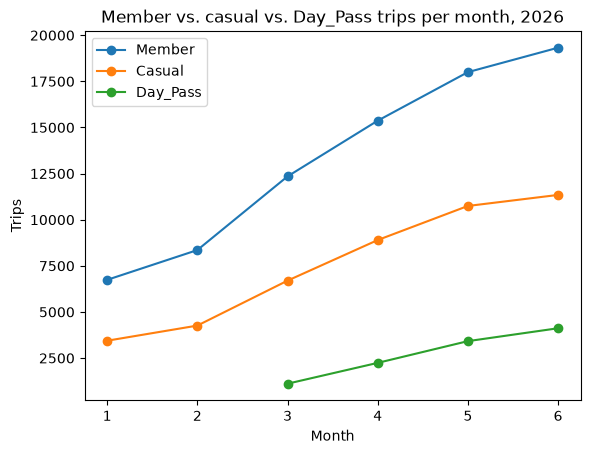

In [44]:
#Which ridership was higher in 2026?

#savefig, then show
rider_by_month = trips_2026.groupby(["month", "rider_type"]).size().unstack()

plt.plot(rider_by_month.index, rider_by_month["member"], label="Member", marker="o") #AI used for identifying correct syntax for indexing and use of the .loc(months used as columns)
plt.plot(rider_by_month.index, rider_by_month["casual"], label="Casual", marker="o")
plt.plot(rider_by_month.index, rider_by_month["day_pass"], label="Day_Pass", marker="o")
plt.title("Member vs. casual vs. Day_Pass trips per month, 2026")
plt.xlabel("Month"); plt.ylabel("Trips"); plt.legend()
plt.savefig("monthly_trips_by_rider_type.png", dpi=150, bbox_inches="tight")
plt.show()

**Member ridership is highest for all months, and the day_pass ridership is the lowest.*

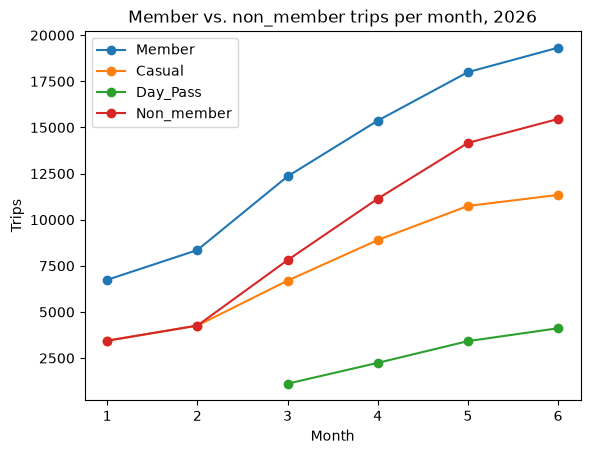

In [45]:
#Four-line chart with legend & markers for rider_types by months including the non_members(casual+day_pass)
#Did day_pass increase non_member ridership?
rider_by_month = trips_2026.groupby(["month", "rider_type"]).size().unstack()
non_member_total = rider_by_month ["casual"].add(rider_by_month ["day_pass"], fill_value=0)

plt.plot(rider_by_month.index, rider_by_month["member"], label="Member", marker="o") #AI used for identifying correct syntax for indexing and use of the .loc(months used as columns)
plt.plot(rider_by_month.index, rider_by_month["casual"], label="Casual", marker="o")
plt.plot(rider_by_month.index, rider_by_month["day_pass"], label="Day_Pass", marker="o")
plt.plot(rider_by_month.index, non_member_total, label="Non_member", marker="o")
plt.title("Member vs. non_member trips per month, 2026")
plt.xlabel("Month"); plt.ylabel("Trips"); plt.legend()
plt.savefig("monthly_trips_with_non_member.png", dpi=150, bbox_inches="tight")
plt.show()

**The non-member ridership is higher than casual ridership for 2026, but we still can't answer whether it increased non-member ridership compared to 2025*

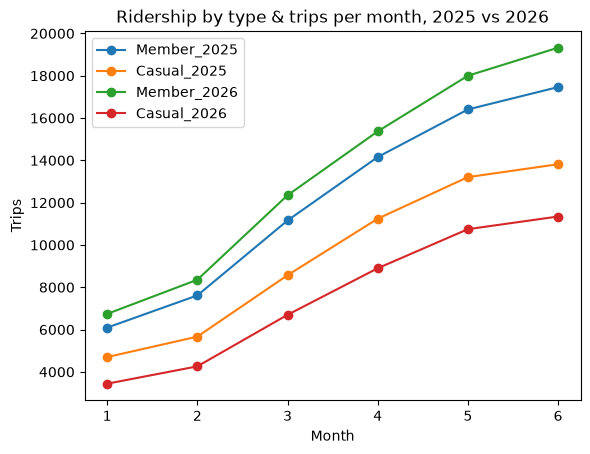

In [46]:
#Did day_pass increase non_member ridership compared to 2025?

monthly_2025 = trips_2025.groupby(["month", "rider_type"]).size().unstack()
rider_by_month = trips_2026.groupby(["month", "rider_type"]).size().unstack()


plt.plot(monthly_2025.index, monthly_2025["member"], label="Member_2025", marker="o")
plt.plot(monthly_2025.index, monthly_2025["casual"], label="Casual_2025", marker="o")
plt.plot(rider_by_month.index, rider_by_month["member"], label="Member_2026", marker="o")
plt.plot(rider_by_month.index, rider_by_month["casual"], label="Casual_2026", marker="o")

plt.title("Ridership by type & trips per month, 2025 vs 2026")
plt.xlabel("Month"); plt.ylabel("Trips"); plt.legend()
plt.savefig("ridership_trips_by_type.png", dpi=150, bbox_inches="tight")
plt.show()

**Did day_pass increase non_member ridership?: This plot shows that member ridership increases in 2026 compared to 2025, but doesn't answer our question still*

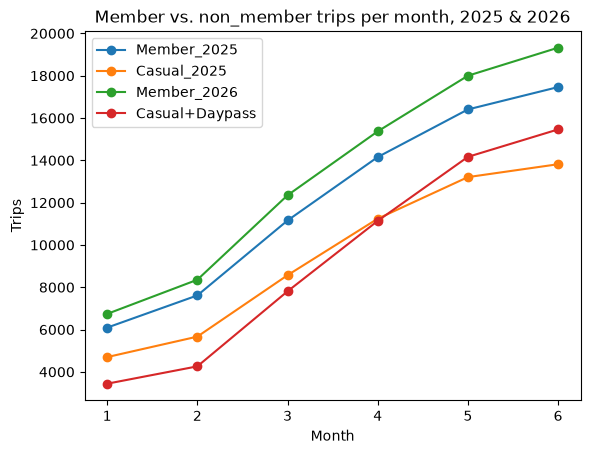

In [47]:
#two-line chart with legend, markers, and axvline at month 7
#          (plot from your Part 5a table -- rider types are columns)

#savefig, then show
monthly_2025 = trips_2025.groupby(["month", "rider_type"]).size().unstack()
rider_by_month = trips_2026.groupby(["month", "rider_type"]).size().unstack()
non_member_total = rider_by_month ["casual"].add(rider_by_month ["day_pass"], fill_value=0)

plt.plot(monthly_2025.index, monthly_2025["member"], label="Member_2025", marker="o")
plt.plot(monthly_2025.index, monthly_2025["casual"], label="Casual_2025", marker="o")

plt.plot(rider_by_month.index, rider_by_month["member"], label="Member_2026", marker="o") #AI used for identifying correct syntax for indexing and use of the .loc(months used as columns)
plt.plot(rider_by_month.index, non_member_total, label="Casual+Daypass", marker="o")
plt.title("Member vs. non_member trips per month, 2025 & 2026")
plt.xlabel("Month"); plt.ylabel("Trips"); plt.legend()
plt.savefig("member_vs_nonmember_monthly_trips.png", dpi=150, bbox_inches="tight")
plt.show()

**This plot confirms non-member ridership increased in 2026 from the casual ridership in 2025. it's not cannibalistic as member ridership increases in 2026 also*

In [48]:
#Did the dock expansion at S06 and S08 at Hodges Library &Student Union UT and station at Fort Sanders neighborhood take of pressure from those stations?
#Merging the trips_2026 and stattions_2026 files to see whether adding stations reduced pressure

trips_2026["has_end"] = ~ trips_2026["end_station_id"].isna()   #creates column for those stations with end_station
ended_2026 = trips_2026 [trips_2026 ["has_end"]]                 #this is the DataFrame we create for the merge step that follows

merged_2026 = pd.merge(                                       #ended_2026 contains all  previous columns including stations with end_station_id
    ended_2026, stations_2026,                                 #Join with original stations_2026 we loaded earlier 
    left_on="end_station_id", right_on="station_id",
    how="left",                                            #Left merge keeps everything from ended_2026 and merges with stations_2026 on end_station_id(left) and station_id(right)
)

per_station_2026 = (
    merged_2026.groupby(["station_name", "neighborhood", "docks"])
    .size()
    .reset_index(name="arrivals_count")
)
per_station_2026["arrivals_per_dock"] = per_station_2026["arrivals_count"] / per_station_2026["docks"] #arrivals_per_dock checks where resources are needed due to congestion

per_station_2026.sort_values("arrivals_per_dock", ascending=True).head(10) #sorted from smallest to largest with ascending=True

,station_name,neighborhood,docks,arrivals_count,arrivals_per_dock
17,Sequoyah Hills Park,Sequoyah Hills,10,1047,104.700000
1,Bearden - Kingston Pike,Bearden,12,1316,109.666667
3,Caswell Park,East Knoxville,10,1573,157.300000
24,Zoo Knoxville,East Knoxville,10,1899,189.900000
20,Suttree Landing Park,South Knoxville,10,1979,197.900000
11,Ijams Nature Center,South Knoxville,10,2113,211.300000
2,Broadway & Central,North Knoxville,12,2724,227.000000
7,Fourth & Gill,North Knoxville,10,2586,258.600000
22,Tyson Park,West Knoxville,12,3427,285.583333
9,Happy Holler,North Knoxville,12,3693,307.750000


**Sequoyah Hills Park,Bearden - Kingston Pike,Caswell Park,Zoo Knoxville have lowest arrivals per dock below 200*

In [49]:
#all end_station_id match with the stations we have in the stations_2026.xlsx file
merged_2026 ["end_station_id"].isin(stations_2026 ["station_id"]).all()

np.True_

In [50]:
print (len (merged_2026)) #132444 trips with end_stations kept and match with the merging process
print (len(ended_2026))

132444
132444


In [51]:
merged_2026 ["end_station_id"].value_counts()

end_station_id
S06    11851
S01    11813
S08    11548
S11     8827
S02     8699
S05     8195
S04     7578
S09     6983
S07     6669
S25     6281
S03     5762
S12     4509
S14     4363
S10     3884
S17     3693
S22     3427
S13     3125
S19     2724
S18     2586
S16     2113
S15     1979
S20     1899
S21     1573
S23     1316
S24     1047
Name: count, dtype: int64

In [52]:
per_station_2026.sort_values("arrivals_per_dock", ascending=True)

,station_name,neighborhood,docks,arrivals_count,arrivals_per_dock
17,Sequoyah Hills Park,Sequoyah Hills,10,1047,104.700000
1,Bearden - Kingston Pike,Bearden,12,1316,109.666667
3,Caswell Park,East Knoxville,10,1573,157.300000
24,Zoo Knoxville,East Knoxville,10,1899,189.900000
20,Suttree Landing Park,South Knoxville,10,1979,197.900000
11,Ijams Nature Center,South Knoxville,10,2113,211.300000
2,Broadway & Central,North Knoxville,12,2724,227.000000
7,Fourth & Gill,North Knoxville,10,2586,258.600000
22,Tyson Park,West Knoxville,12,3427,285.583333
9,Happy Holler,North Knoxville,12,3693,307.750000


**Some of the highest dock arrivals are at Market Square,The Hill - Ayres Hall,Cumberland Ave & 17th St,Gay Street & Union Ave with over 500 arrivals_dock*

<Axes: title={'center': 'Arrivals per dock by station, 2026'}, xlabel='Arrivals per dock'>

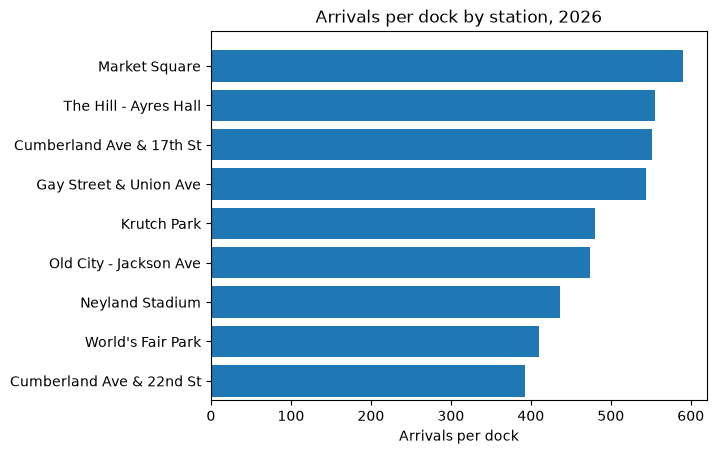

In [60]:
#horizontal bar chart of the 10 most-pressured stations, busiest at top 2026
top = per_station_2026.sort_values("arrivals_per_dock", ascending=True).tail(10)
plt.barh(top["station_name"], top["arrivals_per_dock"])
plt.title("Arrivals per dock by station, 2026")
plt.xlabel("Arrivals per dock")
plt.ylim(bottom = 0.5)
plt.savefig("High_pressure_arrivals_per_dock_2026.png", dpi=150, bbox_inches="tight")
plt.gca()

**Was this different in 2025? We don't see Hodges Library(S06) or Student Union(S08).
Are the stations at Fort Sanders among the pressured ones? Cumberland Ave & 17 St(3rd) and Cumberland Ave & 22nd St(9th)*

<Axes: title={'center': 'Arrivals per dock by station, 2026'}, xlabel='Arrivals per dock'>

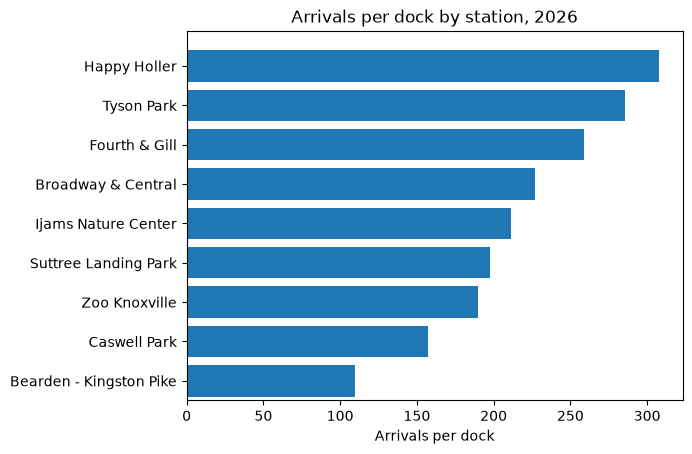

In [54]:
#horizontal bar chart of the 10 least-pressured stations 2026
top = per_station_2026.sort_values("arrivals_per_dock", ascending=True).head(10)
plt.barh(top["station_name"], top["arrivals_per_dock"])
plt.title("Arrivals per dock by station, 2026")
plt.xlabel("Arrivals per dock")
plt.ylim(bottom = 0.5)
plt.savefig("Low_pressure_arrivals_per_dock_2026.png", dpi=150, bbox_inches="tight")
plt.gca()

**Least pressured stations are Bearden-Kingston Pike, Caswell Park, Zoo Knoxville and Suttree Landing Park*

<Axes: title={'center': 'Arrivals per dock by station, 2025'}, xlabel='Arrivals per dock'>

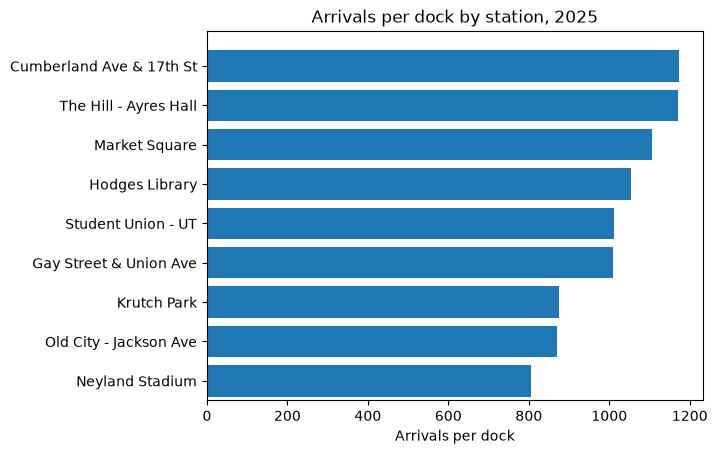

In [55]:
# horizontal bar chart of the 10 most-pressured stations, busiest at top 2025
top = per_station.sort_values("arrivals_per_dock", ascending=True).tail(10)
plt.barh(top["station_name"], top["arrivals_per_dock"])
plt.title("Arrivals per dock by station, 2025")
plt.xlabel("Arrivals per dock")
plt.ylim(bottom = 0.5)
plt.savefig("2025_arrivals_per_dock.png", dpi=150, bbox_inches="tight")
plt.gca()

**Most pressured stations in 2025 were Cumberland Ave & 17th st(1st), The Hill-Ayres Hall, Market Sq., Hodges Library(4th) & Student Union-UT(5th)
In 2026, these two stations rank 13th(Student Union-UT) and 11th(Hodges Library)
and the new station reduces pressure at Fort Sanders, since Cumberland Ave & 17th St moves from 1st to third in pressured station ranking.*

<Axes: title={'center': 'Arrivals per dock by station, 2025'}, xlabel='Arrivals per dock'>

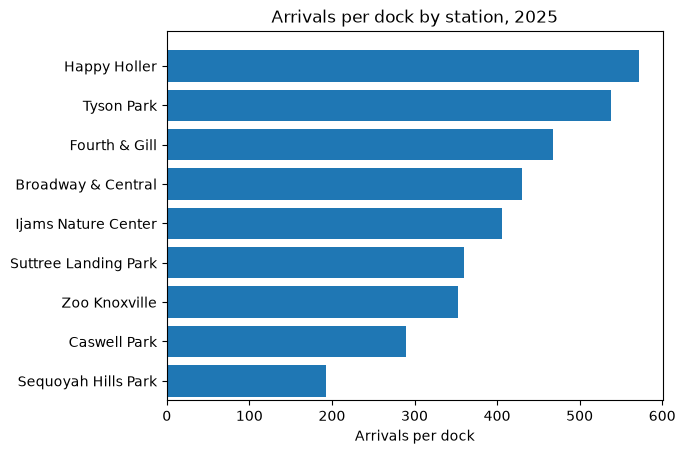

In [56]:
# horizontal bar chart of the 10 least-pressured stations, 2025
top = per_station.sort_values("arrivals_per_dock", ascending=True).head(10)
plt.barh(top["station_name"], top["arrivals_per_dock"])
plt.title("Arrivals per dock by station, 2025")
plt.xlabel("Arrivals per dock")
plt.ylim(bottom = 0.5)
plt.savefig("Low_pressure_arrivals_per_dock_2025.png", dpi=150, bbox_inches="tight")
plt.gca()

**The least pressured stations still remain underutilized with least arrivals per dock*

In [57]:
hourly_trips_2026 = trips_2026.groupby(["hour", "rider_type"]).size().unstack()
print (hourly_trips_2026)

rider_type  casual  day_pass  member
hour                                
0              251        62     227
1              116        22     118
2               54        12     116
3               52        14     116
4              117        37     358
5              200        52    1046
6              451        92    2700
7              881       186    6794
8             1467       337    9492
9             2370       523    4610
10            3186       782    2859
11            3932       976    3369
12            4373      1000    4072
13            3910       935    3299
14            3819       909    3315
15            3361       838    3822
16            3496       868    6137
17            3149       769    9421
18            2787       672    7884
19            2533       649    4552
20            2116       504    2723
21            1472       369    1684
22             837       177     942
23             457       101     482


In [58]:
#How is the weekly ridership by rider_type?
trips_2026.groupby(["day_name", "rider_type"]).size().unstack()

rider_type,casual,day_pass,member
day_name,,,
Friday,6431,839,11522
Monday,6534,847,11672
Saturday,6593,3298,11441
Sunday,6529,3373,11532
Thursday,6369,805,11293
Tuesday,6642,899,11528
Wednesday,6289,825,11150


**day_pass ridership on Saturday and Sunday is around 3300 for both days compared to the average weekly trips of about 800. Day-pass riders use Ride Knox for leisure.*

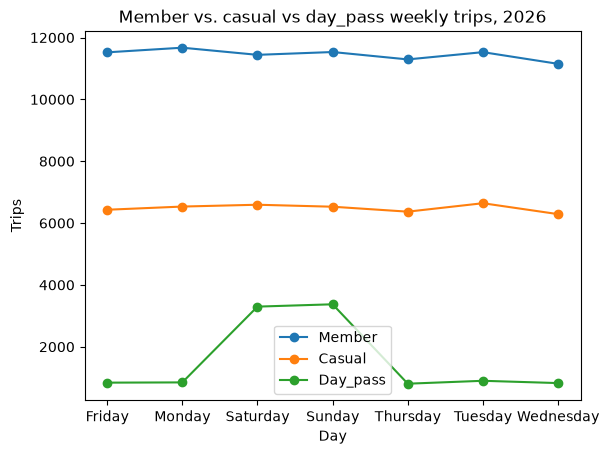

In [59]:
#Three-line chart of hourly rhythms
weekly_trips_2026 = trips_2026.groupby(["day_name", "rider_type"]).size().unstack()
plt.plot(weekly_trips_2026.index, weekly_trips_2026["member"], label="Member", marker="o") #AI used for identifying correct syntax for indexing and use of the .loc(months used as columns)
plt.plot(weekly_trips_2026.index, weekly_trips_2026["casual"], label="Casual", marker="o")
plt.plot(weekly_trips_2026.index, weekly_trips_2026["day_pass"], label="Day_pass", marker="o")
plt.title("Member vs. casual vs day_pass weekly trips, 2026")
plt.xlabel("Day"); plt.ylabel("Trips"); plt.legend()
plt.savefig("2026_rider_type_by_day.png", dpi=150, bbox_inches="tight")
plt.show()

**The day_pass riders are leisure users whose system use spikes on Saturday and Sunday from about 500 to about 3000 trips. This confirms that the day pass product increased non_member ridership whose usability of the system is different from members.*

**To:** Director of Operations
**From:** Charles Munga Muiruri
**Date:** July 2026
**Re:** Day Pass, campus capacity, and who the day-pass riders are

**Bottom line.** The Day Pass has brought non-member ridership back to roughly its 2025 level, and it is
attracting weekend leisure riders rather than converting members. Both campus capacity
changes worked. One 2025 station should be moved.

**Evidence.** Casual single-ride trips fell from 57,198 in January-June 2025 to 45,387 in the same
months of 2026, down 20.6%. Adding the 10,886 day-pass trips brings non-member ridership
to 56,273 against 57,198. June alone is 11.9% above last June. 
Non-members were 44.2% of all June 2025 trips and 44.4% of all June 2026 trips.
Hodges Library and Student Union fell to 11th and 13th position among pressured docks in 2026
from 4th and 5th in 2025. Cumberland Ave & 22nd St opened in March and ranks second of 25. 
Bearden remains 24th of 25; Sequoyah Hills Park is unchanged at last of 25.

**Interpretation.** I read the day-pass numbers as recovering riders the July 2025 price increase pushed out,
but not as members switching down because member ridership increases by 9.9% for 2026. 
61.3% of day-pass trips fall at weekends against 28.9% for
members.

**Limitations.** A Day Pass buys unlimited rides so 10,886 day-pass trips are fewer than 10,886
customers. Without user IDs, the recovery figure is just the upper bound. 
Six months only cannot separate the Day Pass from the price shock fading. 
A January app bug left 800 trips without end timestamps; I kept them for
counting and excluded them from duration operation.

**Recommendation.** Keep Day Pass and check after December. Relocate Sequoyah Hills Park's 10 docks to
the Fort Sanders. Keep Bearden under review for next two years. Ask vendor to
expose pass ID so day-pass customers can be counted, not just trips.

## Reflection + AI Disclosure

**Reflection.**

**The decision that could most change my conclusions is how I counted day-pass riders**
Counting casual trips only, non-member ridership is down 20.6% year over year and the Day 
Pass looks like a failure. Counting casual plus day-pass trips, it is down 1.6% and
rising — June 2026 is 11.9% above last June.

**January bug handling*: Dropping the 800 flagged rows would have led to cutting January and 
February 2026 by about 6% and 2% of their real trips!! dropping them would have lowered the 
pre-launch baseline and made the post-launch improvement look larger than it is.

**Trips-versus-riders problem*: day-pass customers cannot be counted since the record is for trips
and not individual riders which would have shown if really one rider was getting multiple passes
**Memo recommends asking the vendor for a pass ID.*

**AI disclosure.** AI was used to debug and correct syntax. All codes contained herein are mine,
based on the Notebooks I have been working on in the module assignments**

## Submission Checklist

**Kernel → Restart & Run All** — every cell runs top to bottom, no errors

-Row-count audit trail present and complete

-Every judgment call has a written rationale

-All charts titled, axis-labeled with units, legends where needed, saved to `charts`

-The day-pass definitional decision stated

-Dock counts and operating periods handled per year and not merged

-`memo.md` present

-Reflection + AI disclosure completed 

-Zip named `charles_muiruri_python_project.zip` with `project.ipynb`, `memo.md`, `charts`